Experiment - 4 (t-SNE)

---

Name : Shruti Hore

PRN : 24070126172

## Import libraries and load dataset

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.patches as mpatches 
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS, TSNE
from sklearn.metrics.pairwise import euclidean_distances

In [3]:
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.shape

(114000, 21)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [7]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Select relevant features

In [8]:
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms', 'popularity'
]

In [9]:
# cleaning
df = df.dropna(subset=features + ['track_genre'])
df = df.drop_duplicates(subset=['track_id'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89741 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        89741 non-null  int64  
 1   track_id          89741 non-null  object 
 2   artists           89740 non-null  object 
 3   album_name        89740 non-null  object 
 4   track_name        89740 non-null  object 
 5   popularity        89741 non-null  int64  
 6   duration_ms       89741 non-null  int64  
 7   explicit          89741 non-null  bool   
 8   danceability      89741 non-null  float64
 9   energy            89741 non-null  float64
 10  key               89741 non-null  int64  
 11  loudness          89741 non-null  float64
 12  mode              89741 non-null  int64  
 13  speechiness       89741 non-null  float64
 14  acousticness      89741 non-null  float64
 15  instrumentalness  89741 non-null  float64
 16  liveness          89741 non-null  float64
 1

In [10]:
print("Shaper of dataset after cleaning = ", df.shape)

Shaper of dataset after cleaning =  (89741, 21)


In [11]:
# selecting top 8 genres
top = 8
top_genres = df['track_genre'].value_counts().head(top).index.tolist()
df = df[df['track_genre'].isin(top_genres)].copy()
print(f'Filtered : {len(df)} tracks, {top} genres')

Filtered : 7991 tracks, 8 genres


In [12]:
tot = 1200
per_genre = tot // top
df_s = (
    df.groupby('track_genre', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), per_genre), random_state=89))
    .reset_index(drop=True)
)
print(f"Sampled: {len(df_s)} tracks (~{per_genre} per genre)")
X_raw = df_s[features].values
genres = df_s['track_genre'].values


Sampled: 1200 tracks (~150 per genre)


C:\Users\Shruti\AppData\Local\Temp\ipykernel_23128\3563926723.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_genre), random_state=89))


## Standardize

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

## Apply Metric MDS
Metric MDS will try to preserve pairwise distances between the songs

In [14]:
mds = MDS(
    n_components=2,
    dissimilarity='euclidean',
    metric=True, # classical metric MDS
    n_init=4,
    max_iter=500,
    random_state=42,
    n_jobs=-1,
)
X_mds = mds.fit_transform(X)

In [15]:
print(f"MDS stress: {mds.stress_:.4f}")
print('MDS output shape:', X_mds.shape)

MDS stress: 1034091.9492
MDS output shape: (1200, 2)


## Apply t-SNE

In [16]:
D = euclidean_distances(X)
print(f"Distance matrix: {D.shape}")

Distance matrix: (1200, 1200)


In [17]:
tsne = TSNE( n_components=2,
    metric='precomputed',
    perplexity=40,
    learning_rate='auto',
    n_iter=1000,
    init='random', # required when metric='precomputed'
    random_state=42,
    n_jobs=-1,
)
X_tsne = tsne.fit_transform(D)

c:\Users\Shruti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


## Visualization

In [27]:
PALETTE = [
    '#66C2A5',  # muted teal
    '#5DA5DA',  # soft blue
    '#F17CB0',  # soft pink
    '#FF9DA7',  # coral
    '#B276B2',  # muted purple
    '#60BD68',  # green
    '#F5C04A',  # warm yellow (visible!)
    '#FF8C42'   # soft orange
]

In [ ]:
# PALETTE = [
#     '#4E79A7',
#     '#59A14F',
#     '#9C755F',
#     '#76B7B2',
#     '#EDC948',
#     '#AF7AA1',
#     '#FF9DA7',
#     '#E15759'
# ]

In [28]:
genre_list = sorted(top_genres)
color_map = {g: PALETTE[i] for i, g in enumerate(genre_list)}
point_colors = [color_map[g] for g in genres]

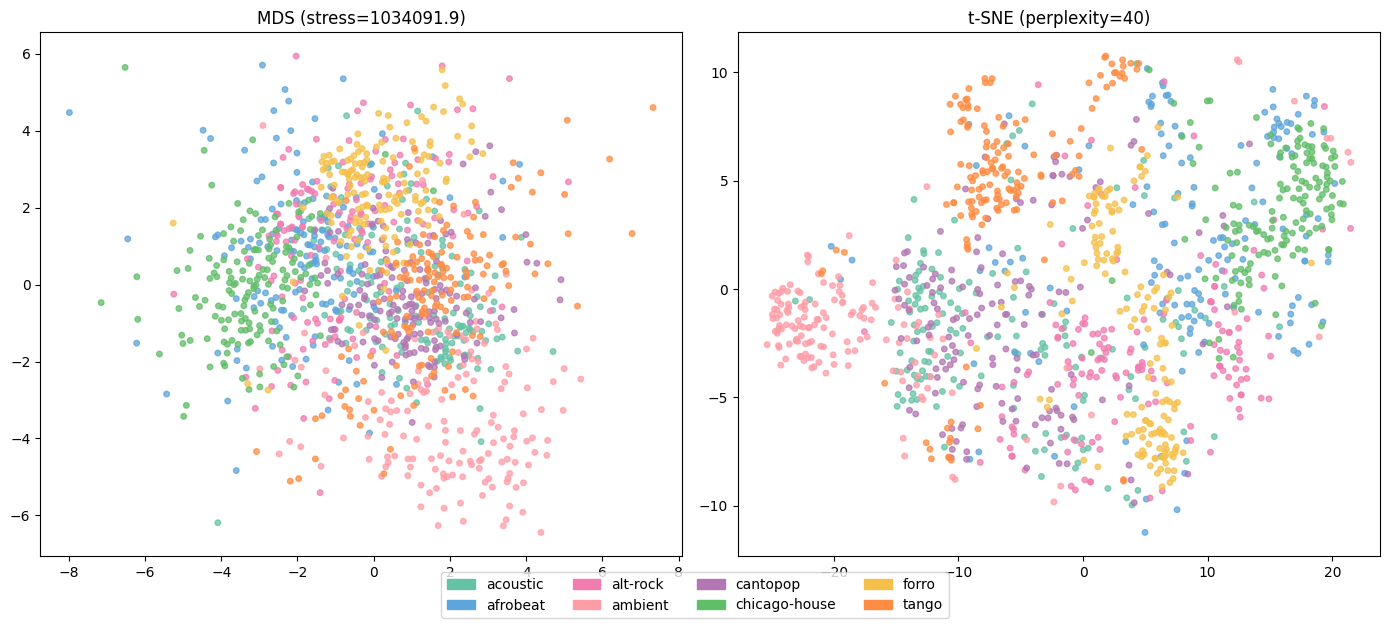

In [29]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, coords, title in zip(
    axes,
    [X_mds, X_tsne],
    [f"MDS (stress={mds.stress_:.1f})", "t-SNE (perplexity=40)"]
):
    ax.scatter(coords[:, 0], coords[:, 1],
               c=point_colors, s=16, alpha=0.75)
    ax.set_title(title)

# legend
handles = [mpatches.Patch(color=color_map[g], label=g) for g in genre_list]

fig.legend(handles=handles,
           loc='lower center',
           ncol=4,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

perplexity = 40


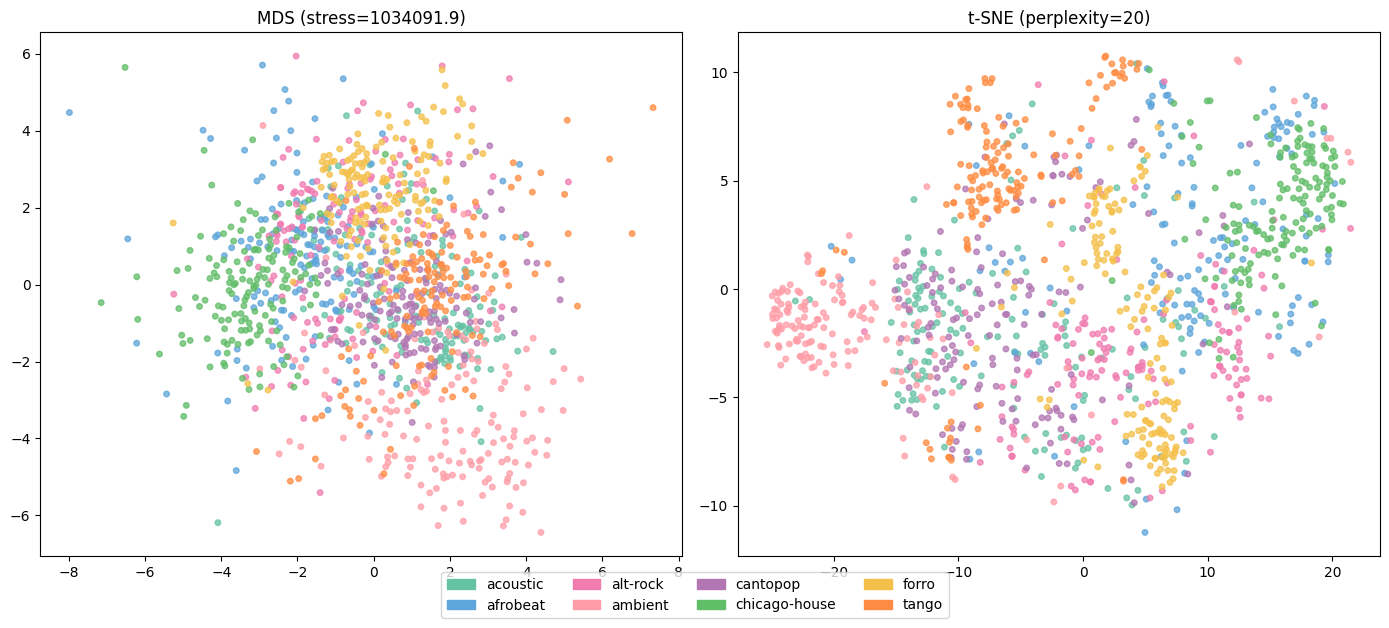

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, coords, title in zip(
    axes,
    [X_mds, X_tsne],
    [f"MDS (stress={mds.stress_:.1f})", "t-SNE (perplexity=20)"]
):
    ax.scatter(coords[:, 0], coords[:, 1],
               c=point_colors, s=16, alpha=0.75)
    ax.set_title(title)

# legend
handles = [mpatches.Patch(color=color_map[g], label=g) for g in genre_list]

fig.legend(handles=handles,
           loc='lower center',
           ncol=4,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

perplexity = 20

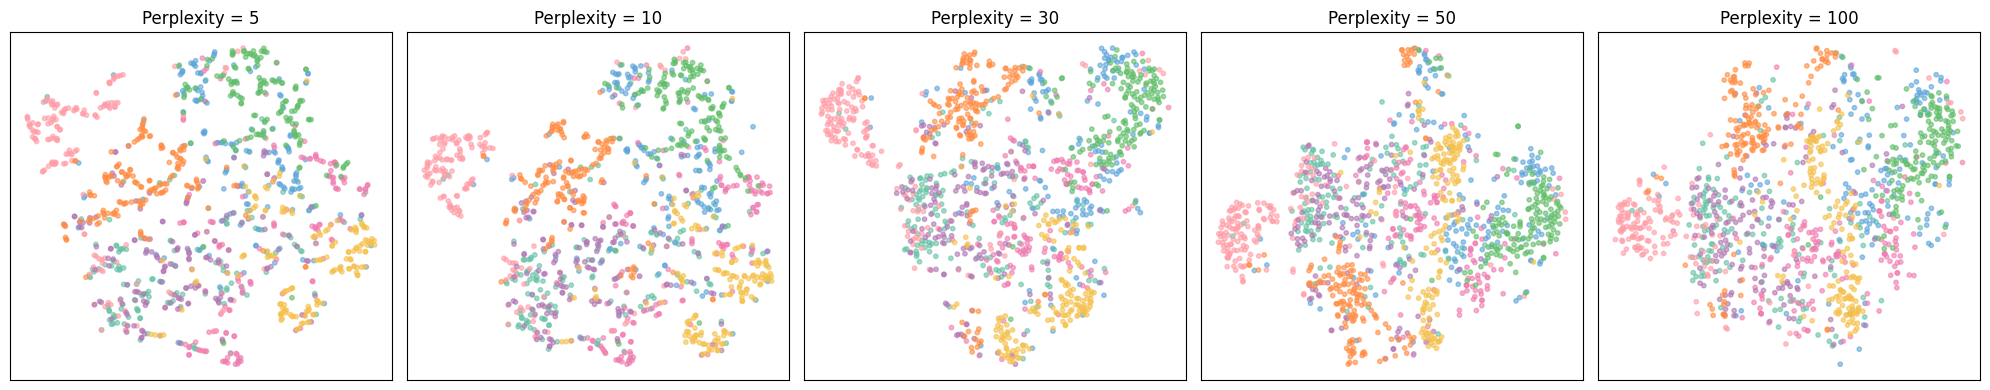

In [31]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

perplexities = [5, 10, 30, 50, 100]

fig, axes = plt.subplots(1, len(perplexities), figsize=(20, 4))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X)

    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1],
                    c=point_colors, s=10, alpha=0.6)
    axes[i].set_title(f'Perplexity = {p}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

The t-SNE analysis demonstrates that a balanced perplexity (30-50) is optimal for capturing the multi-dimensional structure of Spotify audio features. Higher perplexity values emphasize global dataset trends, whereas lower values reveal isolated local similarities, proving that track clustering is highly sensitive to the chosen neighborhood size.